## Adjusting for ABC scores 2/24/26

## Adjusting for new paitents and fewer biomarkers - down to 11 (11/19)

## This data cleaning script is meant to include more high Reagan score patients, and in CA4 biomarker data as given by Jon 10/14

In [2]:
#import the necessary packages even thought probably wont run sustain in this file
import sys #import the local edited python file 
sys.path.insert(0, '/Users/elihallowell/Documents/BU2024/Thesis/sustainrepo/pySuStaIn1')
import pySuStaIn
import re
from pySuStaIn import OrdinalSustain
import numpy as np
import os
from pathlib import Path
import shutil
import matplotlib.pyplot as plt
import pickle
import sklearn.model_selection
import pandas as pd
import pylab
print(pySuStaIn.__file__)

/Users/elihallowell/Documents/BU2024/Thesis/sustainrepo/pySuStaIn1/pySuStaIn/__init__.py


In [3]:
#import the dataset! - 
#only the first page though
#this data sheet has some new patients added with full data 11/19
#/Users/elihallowell/Documents/BU2024/Thesis
data = pd.read_csv('/Users/elihallowell/Documents/BU2024/Thesis/Data/Updated_AD_semiquant_values2.csv')
#data.describe()
data.head()
data.shape

#import the full data sheet
#this data sheet has the same new patients' data added 11/19
#data_fs = pd.read_csv('/Users/elihallowell/Documents/BU2024/Thesis/AD_full_datasheet.csv') 

#adding in the new ABC score patients here:
data_fs = pd.read_csv('/Users/elihallowell/Documents/BU2024/Thesis/Data/AD SuStaIn data_ABCscore.csv') 

In [4]:
# here we need to attach the reagan score data column to this data 
#pull the reagan score column from data_fs and merge only that with the data df, use the ids to match to the correct patients

# Merge Reagan Score column from full dataset into pre-sustain dataset
merged_data = data.merge(
    data_fs[['Case ID', 'NIA-Reagan Score']],  # only keep relevant columns
    on='Case ID',
    how='left'                                # keep all rows from data
)

# Quick check
print("Merged data shape:", merged_data.shape)
print(merged_data[['Case ID', 'NIA-Reagan Score']].head())
display(merged_data.head())

Merged data shape: (737, 19)
  Case ID        NIA-Reagan Score
0   A0001  Intermediate Probility
1   A0005        High Probability
2   A0006        High Probability
3   A0011  Intermediate Probility
4   A0012        High Probability


,Case ID,RHI Exposure,Pathologic Group,Donor age at death,gender,NFT Tau SQ dorsolateral middle frontal,NFT Tau SQ inferior parietal,NFT Tau SQ superior temporal,NFT Tau SQ Calcarine,NFT Tau SQ substantia nigra,Tau SQ Olfactory Bulbs,NFT Tau SQ CA1,NFT Tau SQ CA2,NFT Tau SQ CA4,NFT Tau SQ entorhinal cortex,NFT Tau SQ amygdala,Tau SQ Substantia innominate,Tau SQ Globus pallidus,NIA-Reagan Score
0,A0001,No,NaN,66,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Intermediate Probility
1,A0005,No,NaN,88,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High Probability
2,A0006,No,NaN,71,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High Probability
3,A0011,No,NaN,80,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Intermediate Probility
4,A0012,No,NaN,75,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High Probability


## Visualize the missing data now

Unique Reagan Scores: ['Intermediate Probility' 'High Probability' 'Low Probability' 'Not AD'
 nan]


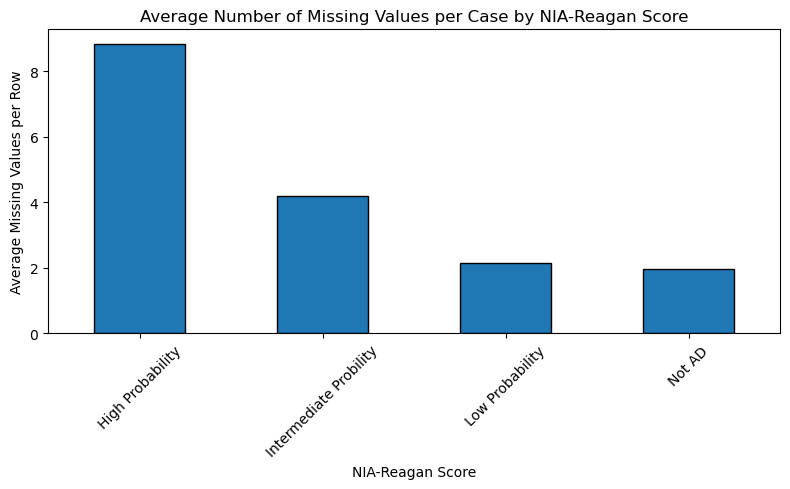

In [5]:
#lets see how many missing values there are per row based on what reagan score assignment is it
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your merged dataframe is called merged_data

# 1. Count missing values per row
merged_data['missing_count'] = merged_data.isna().sum(axis=1)

# 2. Check unique Reagan score values
print("Unique Reagan Scores:", merged_data['NIA-Reagan Score'].unique())

# 3. Create histogram (or bar plot) of missingness by Reagan score
plt.figure(figsize=(8,5))
merged_data.groupby('NIA-Reagan Score')['missing_count'].mean().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Number of Missing Values per Case by NIA-Reagan Score')
plt.xlabel('NIA-Reagan Score')
plt.ylabel('Average Missing Values per Row')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Lets make a cost function to decide which values to remove

In [6]:
#cost = reagan score*3 - (number of missing values)
#make a another column that performs the above operation 
# Ensure the missing_count column exists
merged_data['missing_count'] = merged_data.isna().sum(axis=1)

# Convert Reagan Score to numeric (if not already)
merged_data['NIA-Reagan Score'] = pd.to_numeric(
    merged_data['NIA-Reagan Score'], errors='coerce'
)

# Replace NaN Reagan scores with 0
merged_data['NIA-Reagan Score'] = merged_data['NIA-Reagan Score'].fillna(0)

# Compute cost
merged_data['cost'] = (merged_data['NIA-Reagan Score'] * 3) - merged_data['missing_count']

# Preview
merged_data[['Case ID', 'NIA-Reagan Score', 'missing_count', 'cost']].head()

,Case ID,NIA-Reagan Score,missing_count,cost
0,A0001,0.0,14,-14.0
1,A0005,0.0,14,-14.0
2,A0006,0.0,14,-14.0
3,A0011,0.0,14,-14.0
4,A0012,0.0,14,-14.0


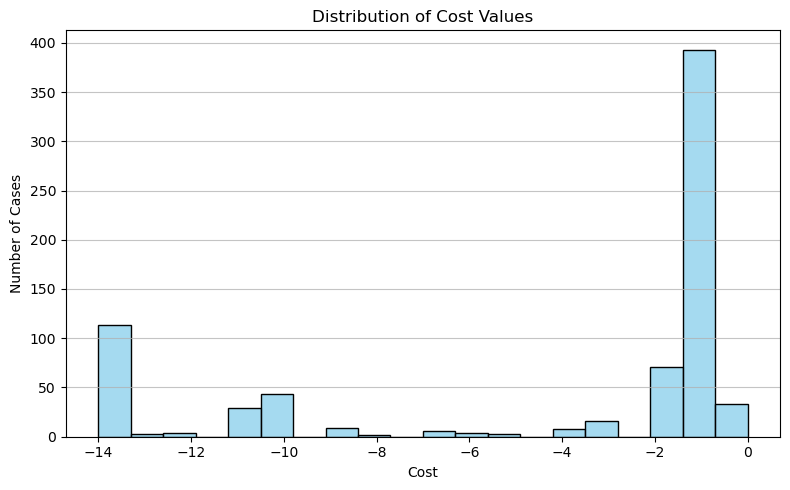

In [7]:
#now view this data as a histogram across cost values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

# Using seaborn for a nicer style
sns.histplot(merged_data['cost'], bins=20, kde=False, color='skyblue', edgecolor='black')

plt.title('Distribution of Cost Values')
plt.xlabel('Cost')
plt.ylabel('Number of Cases')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


## Exclude the case ID's starting with A

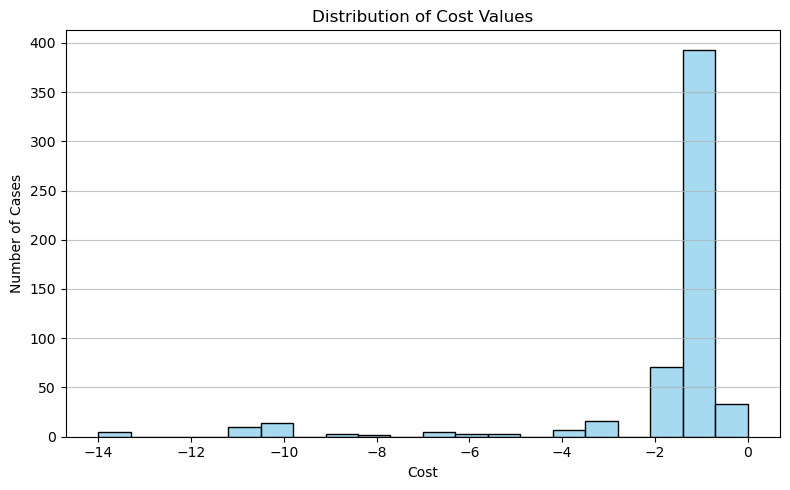

In [8]:
# looks like BVAX and K case IDs have the fewest missing values
# exclude the case ID's starting with A, then show the histogram again above

#Exclude Case IDs starting with 'A'
filtered_data = merged_data[~merged_data['Case ID'].str.startswith('A')].copy()

plt.figure(figsize=(8,5))

# Using seaborn for a nicer style
sns.histplot(filtered_data['cost'], bins=20, kde=False, color='skyblue', edgecolor='black')

plt.title('Distribution of Cost Values')
plt.xlabel('Cost')
plt.ylabel('Number of Cases')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## No Imputation here, just removing all patients who have missing data

### First take out the strings in the biomarkers

In [9]:
# make all the values in the biomarker columns integers (remove the strings)

# Copy your dataset
#using that big mergerd dataset
cleaned_data = merged_data.copy()

# Function to extract numbers from mixed strings
def extract_if_mixed(cell):
    if pd.isna(cell):
        return np.nan  # leave NaN unchanged
    cell_str = str(cell)
    has_digit = bool(re.search(r'\d', cell_str))
    has_letter = bool(re.search(r'[a-zA-Z]', cell_str))
    
    if has_digit and has_letter:  # mixed cell
        match = re.search(r'-?\d+\.?\d*', cell_str)
        return int(float(match.group(0))) if match else np.nan
    else:
        try:
            return int(float(cell_str))  # convert numeric strings to int
        except:
            return np.nan

# Select biomarker columns (from column 6 onward)
biomarker_cols = cleaned_data.columns[5:]

# Apply the function to each biomarker column on imputed data
for col in biomarker_cols:
    cleaned_data[col] = cleaned_data[col].apply(extract_if_mixed)
    
#also do it to the not imputed data
for col in biomarker_cols:
    merged_datacol = merged_data[col].apply(extract_if_mixed)

#now display the data
display(cleaned_data)


,Case ID,RHI Exposure,Pathologic Group,Donor age at death,gender,NFT Tau SQ dorsolateral middle frontal,NFT Tau SQ inferior parietal,NFT Tau SQ superior temporal,NFT Tau SQ Calcarine,NFT Tau SQ substantia nigra,...,NFT Tau SQ CA1,NFT Tau SQ CA2,NFT Tau SQ CA4,NFT Tau SQ entorhinal cortex,NFT Tau SQ amygdala,Tau SQ Substantia innominate,Tau SQ Globus pallidus,NIA-Reagan Score,missing_count,cost
0,A0001,No,NaN,66,Male,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,14,-14
1,A0005,No,NaN,88,Male,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,14,-14
2,A0006,No,NaN,71,Male,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,14,-14
3,A0011,No,NaN,80,Male,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,14,-14
4,A0012,No,NaN,75,Male,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,14,-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
732,SLI146,No,NaN,77,Male,3.0,3.0,3.0,0.0,2.0,...,2.0,2.0,2.0,3.0,3.0,3.0,NaN,0,2,-2
733,SLI159,Yes,Control,50,Male,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0,10,-10
734,SLI161,No,Control,51,Male,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,-1
735,SLI165,Yes,NaN,61,Male,1.0,0.0,1.0,0.0,1.0,...,1.0,2.0,2.0,2.0,2.0,1.0,0.0,0,2,-2


In [10]:
# Trim down the set to exlucde the last two columns
cleaned_data2 = cleaned_data.iloc[:, :-3]
display(cleaned_data2)

,Case ID,RHI Exposure,Pathologic Group,Donor age at death,gender,NFT Tau SQ dorsolateral middle frontal,NFT Tau SQ inferior parietal,NFT Tau SQ superior temporal,NFT Tau SQ Calcarine,NFT Tau SQ substantia nigra,Tau SQ Olfactory Bulbs,NFT Tau SQ CA1,NFT Tau SQ CA2,NFT Tau SQ CA4,NFT Tau SQ entorhinal cortex,NFT Tau SQ amygdala,Tau SQ Substantia innominate,Tau SQ Globus pallidus
0,A0001,No,NaN,66,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A0005,No,NaN,88,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A0006,No,NaN,71,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A0011,No,NaN,80,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A0012,No,NaN,75,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
732,SLI146,No,NaN,77,Male,3.0,3.0,3.0,0.0,2.0,3.0,2.0,2.0,2.0,3.0,3.0,3.0,NaN
733,SLI159,Yes,Control,50,Male,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN
734,SLI161,No,Control,51,Male,0.0,0.0,0.0,0.0,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0
735,SLI165,Yes,NaN,61,Male,1.0,0.0,1.0,0.0,1.0,NaN,1.0,2.0,2.0,2.0,2.0,1.0,0.0


## Now remove NaN values

In [11]:
#remove all NaN values in columns after 5
# Remove all rows with NaNs in columns after the 5th one
cleaned_data3 = cleaned_data2.dropna(subset=cleaned_data2.columns[5:])

# Check result
# 8 more rows (patients) with the update 11/19!
print("Original shape:", cleaned_data2.shape)
print("Cleaned shape:", cleaned_data3.shape)


Original shape: (737, 18)
Cleaned shape: (421, 18)


In [12]:
#check cleaned_data3 for other values outside of 0,1,2,3

# Find row indices with invalid biomarker values
biomarker_data = cleaned_data3.iloc[:, 5:].to_numpy()
invalid_mask = (biomarker_data < 0) | (biomarker_data > 3)
invalid_rows = np.unique(np.where(invalid_mask)[0])

# Drop these rows from the DataFrame
if len(invalid_rows) > 0:
    print(f"Dropping {len(invalid_rows)} rows with invalid biomarker values...")
    cleaned_data3 = cleaned_data3.drop(index=invalid_rows).reset_index(drop=True)
else:
    print("No rows to drop; all biomarker values are valid.")

# Verify
print("New shape of cleaned_data3:", cleaned_data3.shape)

#only had to drop 1 row from an error in the raw data...

No rows to drop; all biomarker values are valid.
New shape of cleaned_data3: (421, 18)


In [13]:
#then export
#---again now using the second data set----
cleaned_data3.to_csv("data_Tau_trimmed6.csv", index=False)
#this is saved to current working directory i.e. /Thesis/sustainrepo/Sustain1/notebooks

## Now we want to also have a dataset that excludes the NoN-AD patients



In [14]:
#load the full data sheet
#data_full = pd.read_csv('/Users/elihallowell/Documents/BU2024/Thesis/AD_full_datasheet.csv')

#just use the one we already imported
data_full = data_fs

# Merge cleaned_data3 with data_full by "Case ID"
cleaned_data4 = pd.merge(cleaned_data3, data_full, on="Case ID", how="inner",suffixes=("", "_drop"))

# Display shape of the results
print(f"\nMerged dataset shape: {cleaned_data4.shape}")


Merged dataset shape: (421, 176)


In [15]:
#exclude the Not AD patients to created a set called cleaned_data5

# Exclude the 'Not AD' patients based on 'NIA-Reagan Score' column
cleaned_data5 = cleaned_data4[cleaned_data4['NIA-Reagan Score'] != 'Not AD'].copy()

# Display first few rows to confirm
print(f"\nNot AD dataset shape: {cleaned_data5.shape}")

#ensure that there are no 'Not AD' cases in the 'NIA Reagan Score' column by counting the number in that column and making sure its 0
not_ad_count = (cleaned_data5['NIA-Reagan Score'] == 'Not AD').sum()
print(f"Number of 'Not AD' entries in 'NIA Reagan Score': {not_ad_count}")
#assert to stop execution if any are found
assert not_ad_count == 0, "Error: There are still 'Not AD' cases present!"

# Cut dataset down to first 18 columns (raw data only)
cleaned_data6 = cleaned_data5.iloc[:, :18].copy()

# Display first few rows of the trimmed dataset
display(cleaned_data6.head())
print(f"\nTrimmed columns Not AD dataset shape (cleaned_data6): {cleaned_data6.shape}")



Not AD dataset shape: (248, 176)
Number of 'Not AD' entries in 'NIA Reagan Score': 0


,Case ID,RHI Exposure,Pathologic Group,Donor age at death,gender,NFT Tau SQ dorsolateral middle frontal,NFT Tau SQ inferior parietal,NFT Tau SQ superior temporal,NFT Tau SQ Calcarine,NFT Tau SQ substantia nigra,Tau SQ Olfactory Bulbs,NFT Tau SQ CA1,NFT Tau SQ CA2,NFT Tau SQ CA4,NFT Tau SQ entorhinal cortex,NFT Tau SQ amygdala,Tau SQ Substantia innominate,Tau SQ Globus pallidus
0,BVAX029,No,NaN,82,Male,2.0,3.0,3.0,2.0,2.0,3.0,3.0,1.0,1.0,3.0,3.0,3.0,0.0
1,BVAX042,No,NaN,92,Male,2.0,1.0,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,0.0
3,BVAX046,No,NaN,86,Female,0.0,0.0,2.0,0.0,2.0,1.0,3.0,2.0,1.0,3.0,2.0,3.0,0.0
5,BVAX056,No,NaN,89,Female,1.0,0.0,1.0,0.0,0.0,3.0,3.0,2.0,1.0,3.0,3.0,3.0,0.0
6,BVAX057,No,NaN,95,Female,1.0,2.0,2.0,1.0,0.0,1.0,2.0,2.0,2.0,3.0,3.0,2.0,0.0



Trimmed columns Not AD dataset shape (cleaned_data6): (248, 18)


## Sort with the ABC column now!

In [22]:
#for ABC score sorting

# Exclude the 'Not AD' patients based on 'ABC' column
cleaned_data5_abc = cleaned_data4[cleaned_data4["NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score)"] != '0 Not AD'].copy()

# UPDATE 2/24/26
# Drop rows where ABC_score is blank or missing
# -------------------------------
cleaned_data5_abc= cleaned_data5_abc[cleaned_data5_abc["NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score)"].notna() & (cleaned_data5_abc["NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score)"] != "")]

#check unique columns
display(cleaned_data5_abc["NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score)"].unique())

#------------------------------


#ensure that there are no 'Not AD' cases in the 'NIA Reagan Score' column by counting the number in that column and making sure its 0
not_ad_count_abc = (cleaned_data5_abc["NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score)"] == '0 Not AD').sum()
print(f"Number of 'Not AD' entries in 'NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score)': {not_ad_count_abc}")
#assert to stop execution if any are found
assert not_ad_count_abc == 0, "Error: There are still 'Not AD' cases present in abc!"


# Cut dataset down to first 18 columns (raw data only)
cleaned_data6_abc = cleaned_data5_abc.iloc[:, :18].copy()


# Display first few rows of the trimmed dataset
display(cleaned_data6_abc.head())
print(f"\nTrimmed columns Not AD dataset shape (cleaned_data6): {cleaned_data6_abc.shape}")



array(['2 Intermediate ADNC', '1 Low ADNC', '3 High ADNC'], dtype=object)

Number of 'Not AD' entries in 'NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score)': 0


,Case ID,RHI Exposure,Pathologic Group,Donor age at death,gender,NFT Tau SQ dorsolateral middle frontal,NFT Tau SQ inferior parietal,NFT Tau SQ superior temporal,NFT Tau SQ Calcarine,NFT Tau SQ substantia nigra,Tau SQ Olfactory Bulbs,NFT Tau SQ CA1,NFT Tau SQ CA2,NFT Tau SQ CA4,NFT Tau SQ entorhinal cortex,NFT Tau SQ amygdala,Tau SQ Substantia innominate,Tau SQ Globus pallidus
0,BVAX029,No,NaN,82,Male,2.0,3.0,3.0,2.0,2.0,3.0,3.0,1.0,1.0,3.0,3.0,3.0,0.0
5,BVAX056,No,NaN,89,Female,1.0,0.0,1.0,0.0,0.0,3.0,3.0,2.0,1.0,3.0,3.0,3.0,0.0
6,BVAX057,No,NaN,95,Female,1.0,2.0,2.0,1.0,0.0,1.0,2.0,2.0,2.0,3.0,3.0,2.0,0.0
7,BVAX060,No,NaN,68,Female,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,2.0,0.0
8,BVAX062,No,NaN,93,Female,2.0,2.0,3.0,3.0,2.0,1.0,3.0,1.0,2.0,3.0,3.0,3.0,0.0



Trimmed columns Not AD dataset shape (cleaned_data6): (301, 18)


## Save the Not AD dataset to a csv for sustain analysis

In [23]:
# Display shape
print(f"\nNot AD dataset shape: {cleaned_data5_abc.shape}")

#saving the data with 'Not AD' Reagan scores excluded, all else the same
cleaned_data6_abc.to_csv("data_Tau_trimmed6_notAD_abc.csv", index=False)


Not AD dataset shape: (301, 176)
